# Big title

## Imports

In [1]:
import os
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.stats import linregress
from scipy.integrate import quad

from TherMIFASOL.core.variables.GlobalVariables import (
    LEQ_PYRO_1, LEQ_PYRO_2, LINES_CRED, COLUMNS_CRED, FTEQ_CRED, LAMBEQ_CRED,
    LAMBDA_NIR, FWHM_NIR, QE_NIR,
)
from TherMIFASOL.core.models.ThermalLaws import (
    wien_law_equivalent, wien_law
)
from TherMIFASOL.core.utils.glob import (
    compute_centered_roi
)
from TherMIFASOL.core.data_processing.PYROMETER_functions import (
    collect_data_pyrometer, pyrometer_emissivity_coefficient
)

from TherMIFASOL.core.data_processing.CRED_functions import (
    load_cred_array, dl_to_thermo
    )

from TherMIFASOL.core.data_processing.XIMEA_functions import (
    get_IT_images, temporal_mean, apply_NUC_XIMEA, split_channel, combine_channels, reconstruct_calibration_flows
    )


In [2]:
PATH_DATA = "/media/dolle/Extreme SSD/DATA_MIFASOL/"
# Work path project
try:
    BASE_DIR = Path(__file__).resolve().parents[2]
except NameError:
    BASE_DIR = Path().resolve().parents[2]

## Devices

### Pyrometer

#### First campaign

In [3]:
list_BB_temperature_C = [550, 650, 700, 750, 800, 850, 900, 950, 1000, 1050, 1100]
INFO = {}

for T_BB_C in list_BB_temperature_C:
    str_data_file_name = os.path.join(
        PATH_DATA, f"calibration/pyrometer/BB_cavity_1/CN{T_BB_C}")
    path_two_color_data = os.path.join(str_data_file_name, f"CN{T_BB_C}_TwoColors.npy")
    path_channel1_data = os.path.join(str_data_file_name, f"CN{T_BB_C}_Channel1.npy")
    path_channel2_data = os.path.join(str_data_file_name, f"CN{T_BB_C}_Channel2.npy")

    temp2C = np.load(path_two_color_data)
    tempK1 = np.load(path_channel1_data)
    tempK2 = np.load(path_channel2_data)
    eps_1 = pyrometer_emissivity_coefficient(
        temperature_bichromatic=temp2C,
        temperature_monochromatic=tempK1,
        lambda_equivalent=LEQ_PYRO_1
    )
    eps_2 = pyrometer_emissivity_coefficient(
        temperature_bichromatic=temp2C,
        temperature_monochromatic=tempK2,
        lambda_equivalent=LEQ_PYRO_2
    )

    INFO[T_BB_C] = {
        'mean' : np.mean(temp2C),
        'std' : np.std(temp2C),
        'emissivity mean 1' : np.mean(eps_1),
        'emissivity std 1' : np.std(eps_1),
        'emissivity mean 2' : np.mean(eps_2),
        'emissivity std 2' : np.std(eps_2)
    }

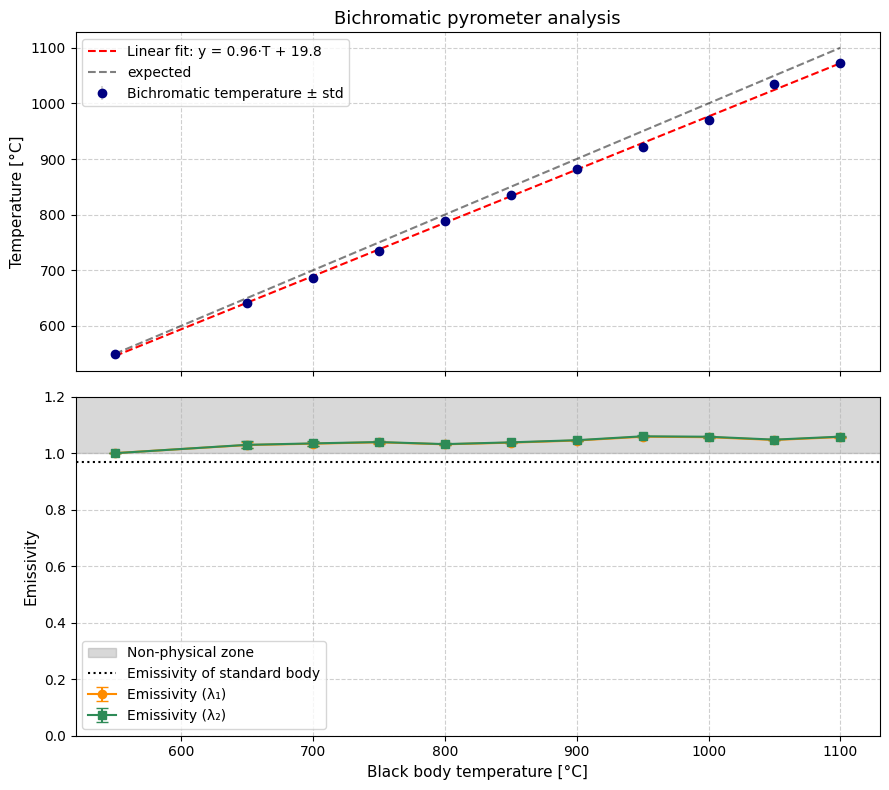

In [4]:
# --- Data extraction ---
temperatures_C = np.array(list_BB_temperature_C)
means = np.array([INFO[T]['mean'] for T in temperatures_C])
stds = np.array([INFO[T]['std'] for T in temperatures_C])

eps1_mean = np.array([INFO[T]['emissivity mean 1'] for T in temperatures_C])
eps1_std = np.array([INFO[T]['emissivity std 1'] for T in temperatures_C])

eps2_mean = np.array([INFO[T]['emissivity mean 2'] for T in temperatures_C])
eps2_std = np.array([INFO[T]['emissivity std 2'] for T in temperatures_C])

# --- Linear regression on temperature ---
slope, intercept, *_ = linregress(temperatures_C, means)
fit_line = slope * temperatures_C + intercept

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

# Top subplot: Bichromatic temperature
ax1.errorbar(
    temperatures_C, means, yerr=stds, fmt='o', color='navy', ecolor='lightgray',
    label='Bichromatic temperature ± std'
)
ax1.plot(temperatures_C, fit_line, '--r', label=f'Linear fit: y = {slope:.2f}·T + {intercept:.1f}')
ax1.plot(temperatures_C, temperatures_C, 'k--', alpha=0.5, label='expected')

ax1.set_ylabel("Temperature [°C]", fontsize=11)
ax1.set_title("Bichromatic pyrometer analysis", fontsize=13)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(fontsize=10)
ax1.set_xlim(520, 1130)

# Bottom subplot: Emissivity curves
EPS_CN = 0.97
ax2.fill_between([300, 1700], 1, 1.5, color='gray', alpha=0.3, label='Non-physical zone')
ax2.hlines(y=EPS_CN, xmin=300, xmax=1700, color='k', ls=':', label='Emissivity of standard body')

ax2.errorbar(
    temperatures_C, eps1_mean, yerr=eps1_std, fmt='o-', color='darkorange',
    label='Emissivity (λ₁)', capsize=4
)
ax2.errorbar(
    temperatures_C, eps2_mean, yerr=eps2_std, fmt='s-', color='seagreen',
    label='Emissivity (λ₂)', capsize=4
)
ax2.set_xlabel("Black body temperature [°C]", fontsize=11)
ax2.set_ylabel("Emissivity", fontsize=11)
ax2.set_ylim(0, 1.2)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()


#### Second campaign

In [6]:
list_BB_temperature_C = [600, 700, 800, 900, 1000, 1100, 1200]
INFO = {}

for T_BB_C in list_BB_temperature_C:
    str_data_file_name = os.path.join(
        PATH_DATA, f"calibration/pyrometer/BB_cavity_2/CSVfiles/CN{T_BB_C}.csv"
        )
    INFO[T_BB_C] = collect_data_pyrometer(csv_path=str_data_file_name)

In [7]:
for T_BB_C in list_BB_temperature_C:
    print(INFO[T_BB_C]['nb data'], f"{INFO[T_BB_C]['temps acquisition']:4f}", f"{INFO[T_BB_C]['FPS mean']:.4f}")

25719 3.347971 7884.3845
34614 4.491107 7881.7072
48235 6.187724 7845.4349
49555 6.462249 7883.7572
38881 5.029695 7831.2778
25061 3.239447 7886.7528
27741 3.550435 7828.2079


In [8]:
keys_mean = {
    'T_2C': 'array temp2C',
    'T_K1': 'array tempK1',
    'T_K2': 'array tempK2',
    'my_T_2C': 'array MAtemp2C',
    'my_eps': 'array MAemissivity',
    'T_device': 'array tempDevice'
}

mean_values = defaultdict(list)
std_values = defaultdict(list)

for T_BB_C in list_BB_temperature_C:
    for key, data_key in keys_mean.items():
        values = INFO[T_BB_C][data_key]
        mean_values[key].append(np.mean(values))
        std_values[key].append(np.std(values))

# Conversion en np.array
for key in keys_mean:
    mean_values[key] = np.array(mean_values[key])
    std_values[key] = np.array(std_values[key])

array_BB_temperature_C = np.array(list_BB_temperature_C)

$\xi_3(T) = \frac{|T_{\text{BB}} - T_{\text{pyro}}|}{T_{\text{BB}}} \times 100$


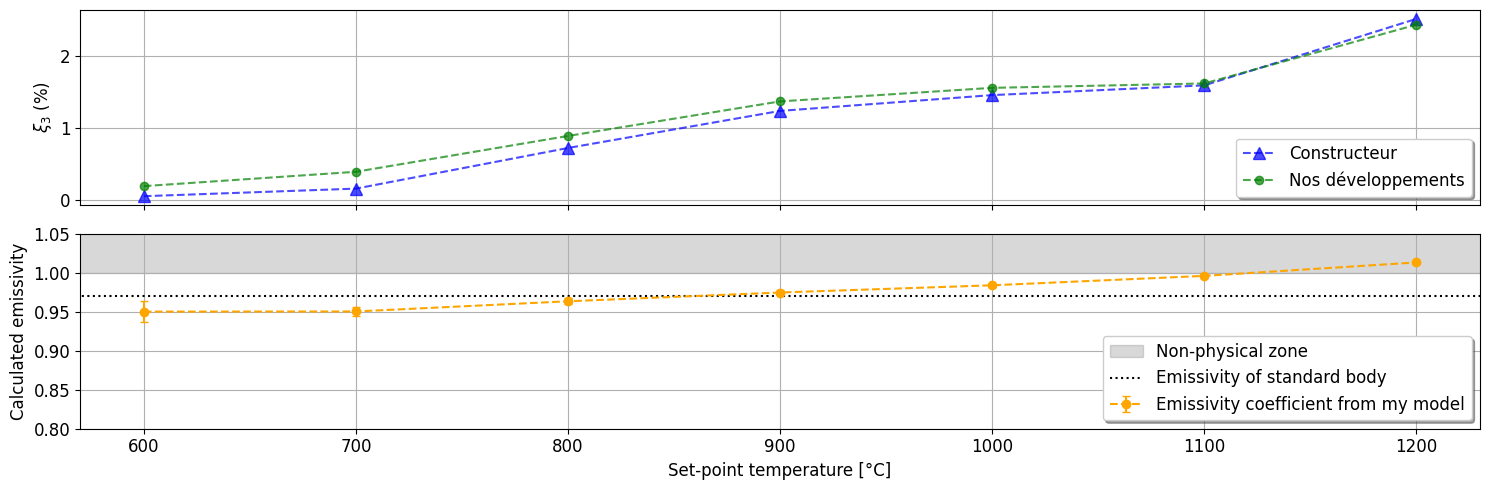

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 5), sharex=True)

ax1.plot(array_BB_temperature_C, 100*np.abs(mean_values['T_2C']-array_BB_temperature_C)/array_BB_temperature_C, 'b^--', ms=8, alpha=0.7, label=f'Constructeur')
ax1.plot(array_BB_temperature_C, 100*np.abs(mean_values['my_T_2C']-array_BB_temperature_C)/array_BB_temperature_C, 'go--', alpha=0.7, label=f'Nos développements')
ax1.set_ylabel(r"$\xi_3$ (%)", fontsize=12)
ax1.legend(loc='lower right', fontsize=12, frameon=True, shadow=True)
ax1.set_xlim(570, 1230)
ax1.tick_params(axis='both', labelsize=12)
ax1.grid(True)

EPS_CN = 0.97
ax2.fill_between([300, 1700], 1, 1.5, color='gray', alpha=0.3, label='Non-physical zone')
ax2.hlines(y=EPS_CN, xmin=300, xmax=1700, color='k', ls=':', label='Emissivity of standard body')

ax2.errorbar(array_BB_temperature_C, mean_values['my_eps'], yerr=std_values['my_eps'], 
             color='orange', fmt='o--', capsize=3, label='Emissivity coefficient from my model'
             )
ax2.set_xlabel('Set-point temperature [°C]', fontsize=12)
ax2.set_ylabel('Calculated emissivity', fontsize=12)
ax2.set_ylim(0.8, 1.05)
ax2.legend(loc='lower right', fontsize=12, frameon=True, shadow=True)
ax2.tick_params(axis='both', labelsize=12)
ax2.grid(True)

fig.tight_layout()
plt.show()

### CRED2Lite

frequency : 600 HZ
|Neutral Density Filter  | Gain | Tuning |  index | IT asked | IT set [s]  |
|--------|----|----|--------|----------|--------------------|
| Oui    | low |  general | 40  |    40e-6   |    42.55e-6   |
| Oui    | low |  general  | 50  |    50e-6   |    52.103e-6  |
| Non    | low |  short time exposure |  2  |      2e-6  |     2.416e-6  |
| Non    | low |  short time exposure |   5  |      5e-6  |     5.6e-6    |
| Non    | low |  short time exposure |   8  |      8e-6  |     8.73e-6   |

- With Neutral density Filter:

The selected integration times at 600 Hz are: 42.55 µs and 52.103 µs.

These times were chosen using a black body at 1200 °C, for which the average digital level at the center of the sensor was 9,218 ADU and 11,930 ADU, respectively. Additionally, a value of approximately 60 µs yields 14,139 ADU.

- Without Neutral Density Filter:

The selected integration times at 600 Hz are: 2.416 µs, 5.6 µs, and 8.73 µs.

These times were chosen using a black body at 1200 °C, where the average digital levels at the center of the sensor were 5,933 ADU, 10,350 ADU, and 11,375 ADU, respectively. Additionally, a value of approximately 11.9 µs gives 11,039 ADU, with a depolarization effect observed at the center.

In [10]:
IT_asked = [2, 5, 8, 40, 50]
save_results = True
black_body_temperatures_C = np.array(
    [500, 550, 600, 650, 700, 750, 800, 850, 900, 950, 1000, 1050, 1100, 1150, 1200]
)
Nb_BB_measurement = len(black_body_temperatures_C)

# Map integration time to sub-path
IT_to_subpath = {
    (2, 5, 8): "WithoutNeutralDensity",
    (40, 50): "WithNeutralDensity"
}


In [12]:
row_s, row_e, col_s, col_e = compute_centered_roi(
    shape=(LINES_CRED, COLUMNS_CRED),
    percent=0.3
    )

roi_results = {}

for it in IT_asked:
    # Determine sub-path from IT group
    sub_path = None
    for group, sub in IT_to_subpath.items():
        if it in group:
            sub_path = sub
            break
    if sub_path is None:
        raise ValueError(f"Unsupported IT: {it}")

    mean_values = []
    for T in black_body_temperatures_C:
        path_data = os.path.join(
        PATH_DATA, f"calibration/CRED2Lite/FLUX/{sub_path}/CN{T}_IT{it}/data"
        )
        frame_list = [
            np.load(os.path.join(path_data, f"{path_data}/im_{i}.npy"))
            for i in range(200)
        ]
        frame_stack = np.mean(np.stack(frame_list), axis=0)
        mean_roi = np.mean(frame_stack[row_s:row_e, col_s:col_e])
        mean_values.append(mean_roi)

    roi_results[it] = mean_values

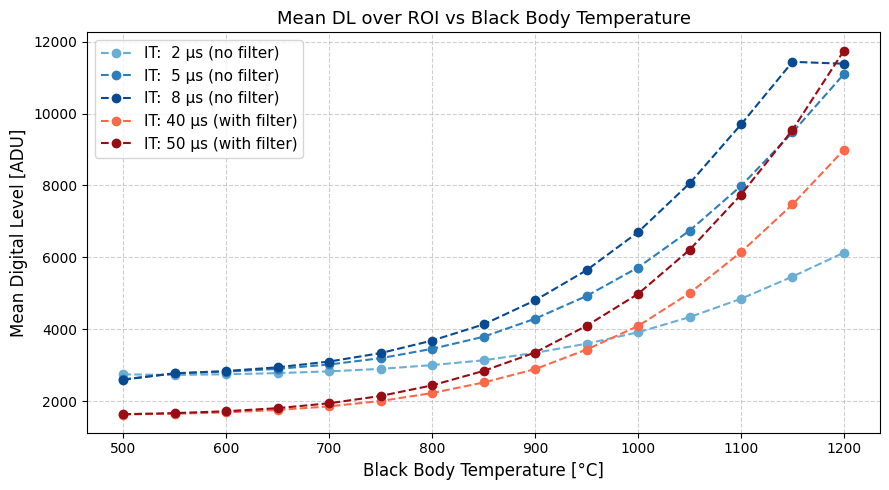

In [14]:
# Group integration times
group_1 = [2, 5, 8]       # Without filter → blue shades
group_2 = [40, 50]        # With filter → red shades

# Define color maps
colors_1 = plt.cm.Blues(np.linspace(0.5, 0.9, len(group_1)))
colors_2 = plt.cm.Reds(np.linspace(0.5, 0.9, len(group_2)))

# Plotting
plt.figure(figsize=(9, 5))

# Plot group 1
for i, it in enumerate(group_1):
    plt.plot(
        black_body_temperatures_C, roi_results[it],
        'o--', color=colors_1[i], label=f'IT: {it:2d} µs (no filter)'
    )

# Plot group 2
for i, it in enumerate(group_2):
    plt.plot(
        black_body_temperatures_C, roi_results[it],
        'o--', color=colors_2[i], label=f'IT: {it} µs (with filter)'
    )

# Labels and legend
plt.title("Mean DL over ROI vs Black Body Temperature", fontsize=13)
plt.xlabel("Black Body Temperature [°C]", fontsize=12)
plt.ylabel("Mean Digital Level [ADU]", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


In [15]:
# Integration times and selected working IT
IT = 40  # µs

# Determine sub-path
sub_path = None
for valid_group, path in IT_to_subpath.items():
    if IT in valid_group:
        sub_path = path
        break

if sub_path is None:
    raise ValueError(f"Unsupported integration time: {IT}")

print(sub_path)

WithNeutralDensity


In [16]:
# Calibration path
path_data = os.path.join(PATH_DATA, f"calibration/CRED2Lite/FLUX/{sub_path}")

# Load NUC (Non-Uniformity Correction) table
path_table_NUC = os.path.join(BASE_DIR, f"TherMIFASOL/resources/tables/NUC/NUC_2pts_Temp550_{sub_path}.npy")
table_NUC = np.load(path_table_NUC)
NUC_degree = table_NUC.shape[2]

# Compute theoretical flux using Wien's law
FLUX_theoretical = wien_law_equivalent(
    temperature=black_body_temperatures_C + 273.15,  # Convert °C to K
    FT_equivalent=FTEQ_CRED,
    wavelength_equivalent=LAMBEQ_CRED
)

# Polynomial degree for flux calibration
flux_poly_degree = 1

In [17]:
# Compute a centered ROI (manually override for now)
roi_bounds = compute_centered_roi(
    shape=(LINES_CRED, COLUMNS_CRED),
    percent=0.3
)
row_start, row_end, col_start, col_end = roi_bounds

# Manually defined ROI override
row_start, row_end, col_start, col_end = 228, 297, 313, 378

##### Compute mean DL over ROI

In [18]:
DL_raw = np.zeros((Nb_BB_measurement, LINES_CRED, COLUMNS_CRED))
DL_corrected = np.zeros((Nb_BB_measurement, LINES_CRED, COLUMNS_CRED))
DL_mean_ROI = np.zeros(Nb_BB_measurement)

for i, temp in enumerate(black_body_temperatures_C):
    frames = []
    for j in range(200):
        frame_path = os.path.join(path_data, f"CN{temp}_IT{IT}/data/im_{j}.npy")
        frames.append(np.load(frame_path))
    
    # Average temporal raw data
    DL_raw[i] = np.mean(frames, axis=0)

    # Apply NUC correction
    for deg in range(NUC_degree):
        DL_corrected[i] += table_NUC[:, :, deg] * DL_raw[i]**(NUC_degree - (deg + 1))

    # Compute mean digital level over the ROI
    DL_mean_ROI[i] = np.mean(DL_corrected[i, row_start:row_end, col_start:col_end])

# Fit a polynomial to the corrected digital levels vs theoretical flux
flux_calibration_coeffs = np.polyfit(DL_mean_ROI, FLUX_theoretical, flux_poly_degree)

In [19]:
save_table = False
if save_table:
    np.save(
        file=os.path.join(BASE_DIR, f"TherMIFASOL/resources/tables/FLUX/FLUX_IT{IT}_deg{flux_poly_degree}_NUC2.npy"),
        array=flux_calibration_coeffs
    )

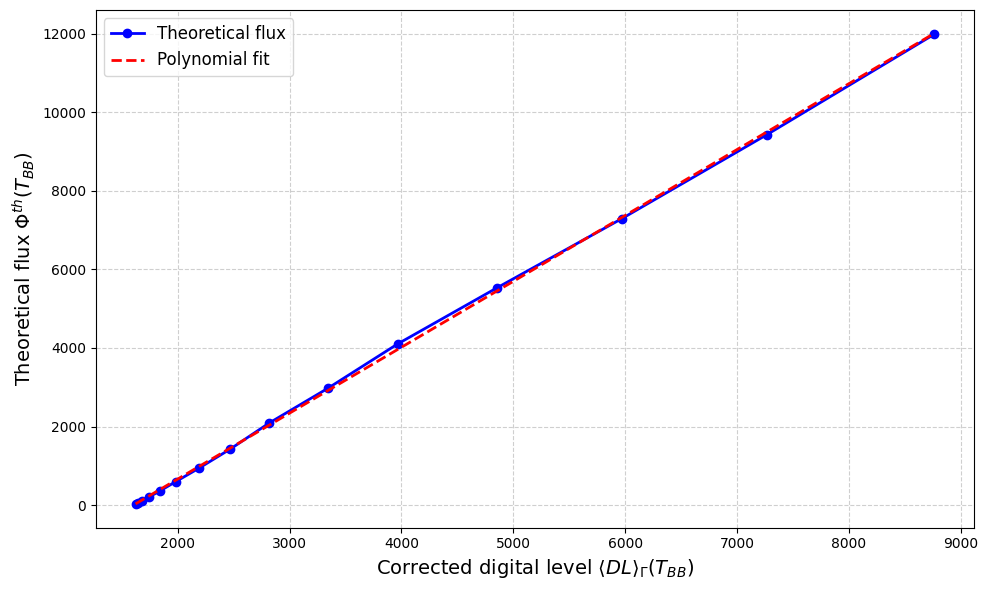

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot theoretical flux
ax.plot(
    DL_mean_ROI, FLUX_theoretical,
    label="Theoretical flux", color='blue',
    marker='o', linestyle='-', linewidth=2
)

# Plot polynomial fit
flux_fit = np.poly1d(flux_calibration_coeffs)
ax.plot(
    DL_mean_ROI, flux_fit(DL_mean_ROI),
    label="Polynomial fit", color='red',
    linestyle='--', linewidth=2
)

# Labels and formatting
ax.set_ylabel(r"Theoretical flux $\Phi^{th}(T_{BB})$", fontsize=14)
ax.set_xlabel(r"Corrected digital level $\langle DL \rangle_{\Gamma}(T_{BB})$", fontsize=14)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=12)

plt.tight_layout()
if save_results:
    save_path = f"{BASE_DIR}/results/calibration/FLUX/CRED/"
    plt.savefig(f"{save_path}/flux_vs_DL_{sub_path}_IT{IT}.png", dpi=150)
    
plt.show()
plt.close(fig)

In [23]:
# Initialize array to store temperature values calculated from NUC + flux calibration
calculated_temperatures_C = np.zeros(Nb_BB_measurement)

for i, T_BB_C in enumerate(black_body_temperatures_C):
    # Randomly pick a frame
    rand_id = np.random.randint(200)
    frame_path = os.path.join(path_data, f"CN{T_BB_C}_IT{IT}/data/im_{rand_id}.npy")
    frame = load_cred_array(frame_path)

    # Convert DL → temperature (in °C)
    thermo_image = dl_to_thermo(
        dl_raw=frame,
        nuc_table=table_NUC,
        calibration_table=flux_calibration_coeffs,
        emissivity=0.99
    ) - 273.15  # Convert from Kelvin to Celsius

    # Average over ROI
    calculated_temperatures_C[i] = np.nanmean(thermo_image[row_start:row_end, col_start:col_end])


/home/dolle/Documents/3_These doctorat/6_python/Thermique MIFASOL/TherMIFASOL/core/data_processing/CRED_functions.py:102: RuntimeWarning: invalid value encountered in log
  return C2 / (wien_equivalent_wavelength * np.log(wien_equivalent_factor * C1 * wien_equivalent_wavelength**-5 / flux))


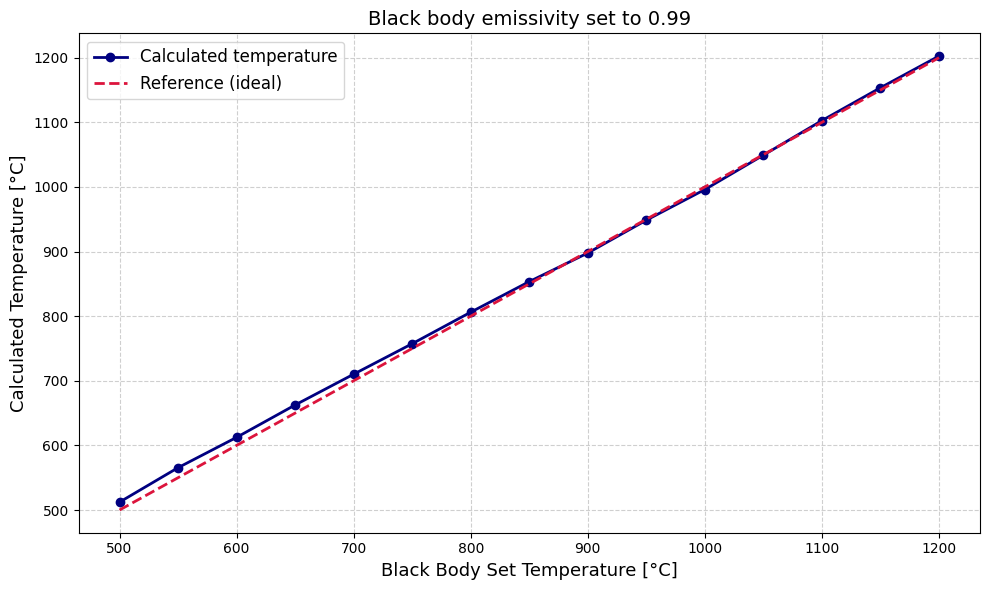

Mean absolute error: 6.48 °C


In [24]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot calculated temperatures
ax.plot(
    black_body_temperatures_C, calculated_temperatures_C,
    label="Calculated temperature", color='navy',
    marker='o', linestyle='-', linewidth=2
)

# Plot identity line (perfect calibration reference)
ax.plot(
    black_body_temperatures_C, black_body_temperatures_C,
    label="Reference (ideal)", color='crimson',
    linestyle='--', linewidth=2
)

# Labels and formatting
ax.set_title(f"Black body emissivity set to 0.99", fontsize=14)
ax.set_xlabel("Black Body Set Temperature [°C]", fontsize=13)
ax.set_ylabel("Calculated Temperature [°C]", fontsize=13)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=12)
plt.tight_layout()
if save_results:
    save_path = f"{BASE_DIR}/results/calibration/FLUX/CRED/"
    plt.savefig(f"{save_path}/Temperature_set_vs_calculated_{sub_path}_IT{IT}.png", dpi=150)
    
plt.show()
plt.close(fig)

abs_error = np.abs(calculated_temperatures_C - black_body_temperatures_C)
print(f"Mean absolute error: {np.nanmean(abs_error):.2f} °C")

### XIMEA

Calibration ran over 12 differents integration time (0 -> 11) and within the range of 850°C up to 1200°C.

In [3]:
labels_IT = np.arange(0, 12)
T_CN_etalonnage=[850, 900, 950, 1000, 1050, 1100, 1150, 1200]
colors = plt.cm.viridis(np.linspace(0, 1, 25))

In [4]:
def gaussian(wavelength, wavelength_center, I_max, FWHM):
    """Réponse du capteur en forme de gaussienne."""
    sigma = FWHM / (2 * np.sqrt(2 * np.log(2)))
    return I_max * np.exp(-0.5 * ((wavelength - wavelength_center) / sigma)**2)


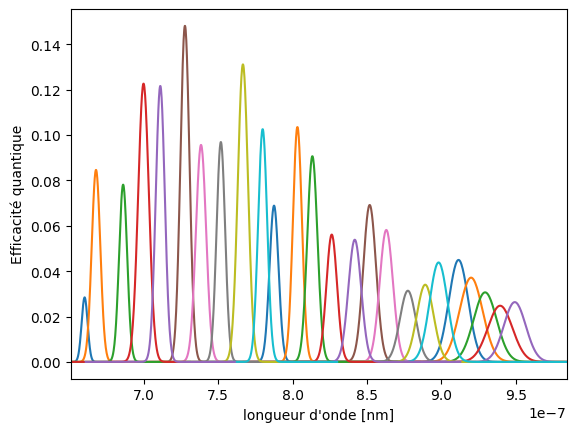

In [5]:
for ch in range(25):

    l_m=LAMBDA_NIR[ch]
    FWHM=FWHM_NIR[ch]
    QE=QE_NIR[ch]

    lambda_=np.linspace(l_m-7*FWHM, l_m+7*FWHM, 500)
    pic = gaussian(
        wavelength=lambda_,
        wavelength_center=l_m,
        I_max=QE,
        FWHM=FWHM
    )
    plt.plot(lambda_, pic, label=f'canal: {ch}')

plt.xlabel("longueur d'onde [nm]")
plt.ylabel("Efficacité quantique")
plt.xlim(
    left=(np.min(LAMBDA_NIR)-2*FWHM_NIR[np.argmin(LAMBDA_NIR)]),
    right=(np.max(LAMBDA_NIR)+2*FWHM_NIR[np.argmax(LAMBDA_NIR)])
    )
plt.show()

In [6]:
def FluxTheorique(T_kelvin, chanel):

    wavelength_min, wavelength_max = 500e-9, 1200e-9
    lambda_c=LAMBDA_NIR[chanel]
    Imax=QE_NIR[chanel]
    FWHM=FWHM_NIR[chanel]

    def integrand(wavelength):
        return wien_law(wavelength, T_kelvin) * gaussian(wavelength, lambda_c, Imax, FWHM)

    return quad(integrand, wavelength_min, wavelength_max)

In [7]:
path_NUC_XIMEA = os.path.join(
    BASE_DIR, f"TherMIFASOL/resources/tables/NUC/XIMEA/NUC_lumiere_photographe_2pts.npy"
)
table_NUC_XIMEA=np.load(path_NUC_XIMEA)


ROI=0.15
sub_lin, sub_col = 1088//np.sqrt(25) , 2048//np.sqrt(25)
ROI_col_lim_inf, ROI_col_lim_sup = int(sub_col*0.5*(1-ROI)), int(sub_col*0.5*(1+ROI))
ROI_lin_lim_inf, ROI_lin_lim_sup = int(sub_lin*0.5*(1-ROI)), int(sub_lin*0.5*(1+ROI))


In [8]:
values_IT={f'IT{i}':None for i in labels_IT}
DATA={}

## Flux théorique associé au Corps NOIR cavité:
Phi_theo=np.zeros((25, len(T_CN_etalonnage)))
for cpt, Temp_CN in enumerate(T_CN_etalonnage):
    for chanel in np.arange(25):
        Phi_theo[chanel, cpt] = FluxTheorique(Temp_CN + 273.15, chanel)[0]

## DL moyen en fonction de la température CN:
"""3 --> 102 µs"""
# for it_id in [3]:
for it_id in labels_IT:
    
    data={
        'it value':[],
        'TCN':T_CN_etalonnage
    }
    mean_DL = []
    for temperature in T_CN_etalonnage:
        path_data = os.path.join(
            PATH_DATA, f"calibration/XIMEA/FLUX/XIQ_{temperature}_{it_id}"
        )
        it_value=get_IT_images(path_data_TCN=path_data)
        data['it value'].append(it_value)

        frame=temporal_mean(path_data_TCN=path_data)
        frame_NUC = apply_NUC_XIMEA(
            image=frame, 
            table=table_NUC_XIMEA
        )
        multi_frame=split_channel(img_to_split=frame_NUC)


        mean_DL.append(
            np.mean(multi_frame[:, ROI_col_lim_inf:ROI_col_lim_sup, ROI_lin_lim_inf:ROI_lin_lim_sup], axis=(1,2))
        )
    mean_DL=np.asarray(mean_DL)
    for ch in range(25):
        data[f'DL_ch {ch}'] = mean_DL[:,ch]

    DATA.update({it_id:data})



## Temperature VS Digital Levels

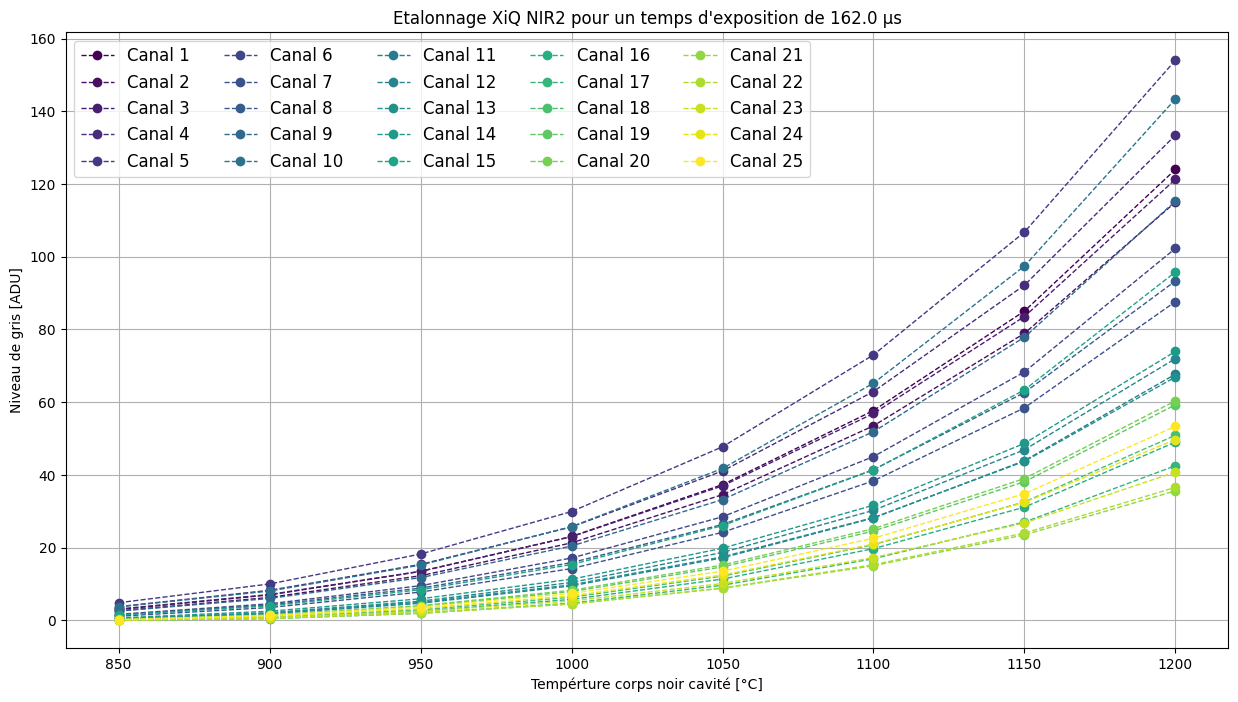

In [9]:
target_it_label=8
sub_data=DATA[target_it_label]

plt.figure(figsize=(15, 8))
it_value=np.mean(np.asarray(sub_data['it value']))
for ch in range(25):
    plt.plot(T_CN_etalonnage, sub_data[f"DL_ch {ch}"],'o--', lw=1, label=f'Canal {ch+1}', color=colors[ch]) 

plt.xlabel('Tempérture corps noir cavité [°C]')
plt.ylabel('Niveau de gris [ADU]')
plt.title(f"Etalonnage XiQ NIR2 pour un temps d'exposition de {it_value} µs")
plt.legend(ncols=5, fontsize=12)  
plt.grid(True)  
# plt.savefig(f"./calibration_XIQ/resultats/NIR_{it_value:.0f}us_afterNUC.png")
# plt.close(fig)
plt.show()

## Flux VS Digital Levels

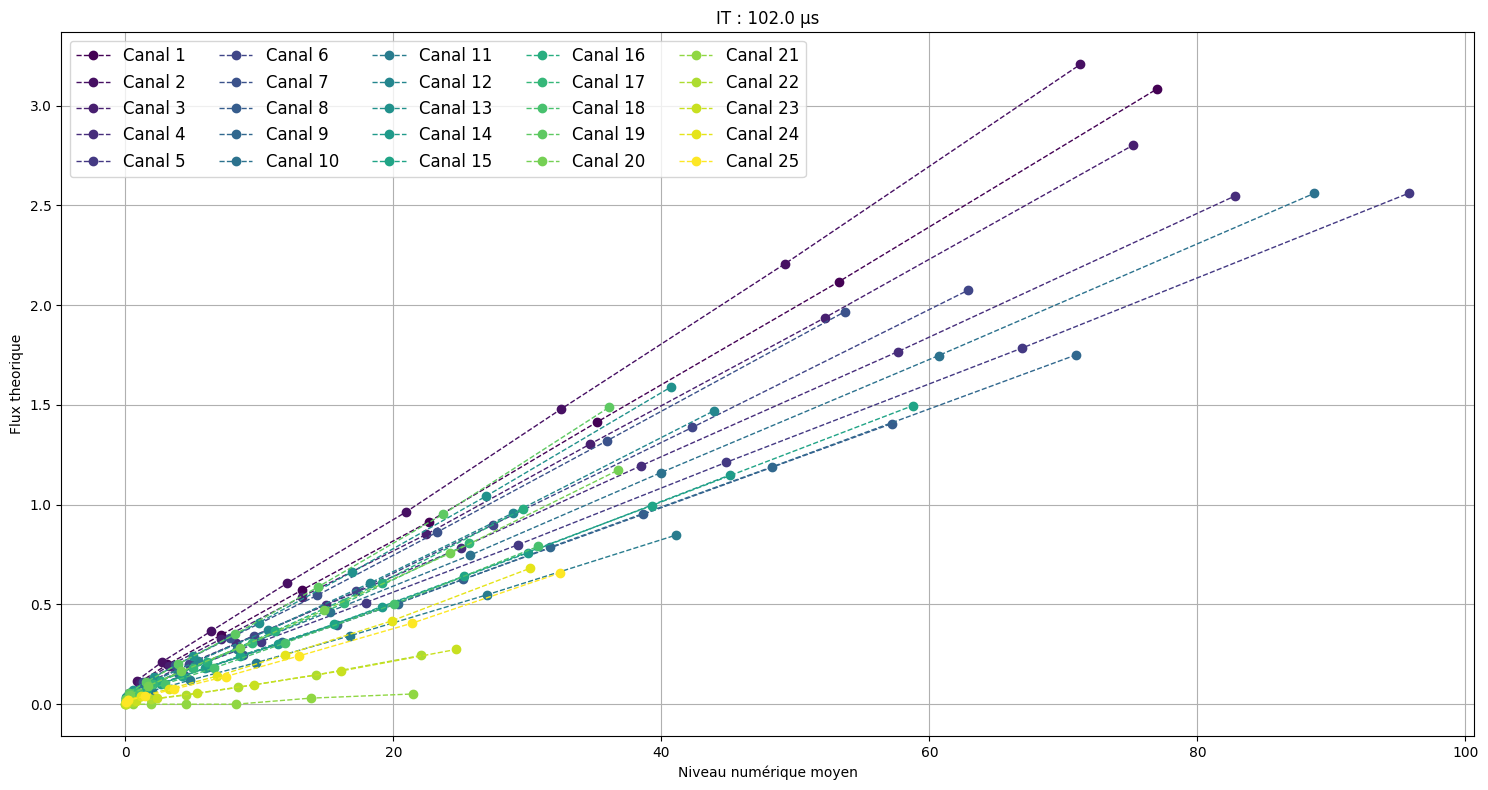

In [10]:
for it_id in [3]:
    # for it_id in labels_IT:

    fig, ax = plt.subplots(figsize=(15, 8))
    for ch in np.arange(25):
        it_value=np.mean(DATA[it_id]['it value'])

        DL_mean=DATA[it_id][f'DL_ch {ch}']
        Flux_theo=Phi_theo[ch]

        ax.plot(DL_mean, Flux_theo, 'o--', lw=1, label=f'Canal {ch+1}', color=colors[ch])

    ax.set_xlabel("Niveau numérique moyen")
    ax.set_ylabel('Flux theorique')
    ax.set_title(f'IT : {it_value} µs')
    ax.grid(True)
    plt.legend(ncols=5, fontsize=12)
    plt.tight_layout()
    
    # plt.savefig(f'NIR_{it_value:0.0f}us_flux_after_NUC.png')
    # plt.close(fig)
    plt.show()

## Create table

In [11]:
it_id = 4
for it_id in labels_IT:
    coeff_flux = []
    for ch in np.arange(25):
        DL_mean=DATA[it_id][f'DL_ch {ch}']
        Flux_theo=Phi_theo[ch]

        coeff_flux.append(np.polyfit(
            x=DL_mean[4:],
            y=Flux_theo[4:],
            deg=1
            )
        )
    coeff_flux=np.asarray(coeff_flux)
    A__, B__ = coeff_flux.T

    C__ = reconstruct_calibration_flows(A__, B__)
    #np.save(f"./calibration_XIQ/tables/table_flux_IT{it_id}_afterNUC.npy", C__)
